# Face-inversion decoder — showcase on one subject's data

A hands-on companion to `decoding_ridge.ipynb`. That notebook *measured* how well
face inversion (upright **UP** vs inverted **IN**) can be linearly decoded from a
CORnet-S layer's population code. Here we **train one decoder on a single subject**
(subject 3) and then watch it read out the orientation of **faces it never saw**.

## What actually generalises — read this first

We tested two versions of "hand it a new face", and they give very different answers:

- **A novel face of the *same stimulus type*** — another subject's video of small
  *printed* faces, cropped by the *same* YuNet→CORnet pipeline. The subject-3 decoder
  transfers **strongly** here: AUC ≈ 0.82–0.97 across the other subjects' videos
  (one weak subject aside). **This is the real showcase**, and it is what §2–§4 below do.
- **An arbitrary internet portrait or phone photo.** This is **off the training
  manifold** — different camera, resolution, framing and scale from the printed-face
  stimuli — and the decoder is **unreliable** on it (margins collapse toward zero, and
  the sign is often wrong). §5 includes it *only* as an honest stress test, clearly
  labelled, so you can see the failure rather than be misled by it.

Almost — just one ordering fix. Scaling and PCA aren't part of the ridge model; they come before it. The three are a pipeline, applied in order:

1. CORnet-S → IT activation vector (25,088 numbers)
2. StandardScaler → z-score those numbers
3. PCA → compress to 44 numbers
4. RidgeClassifier → takes those 44 numbers, computes the margin, decides UP vs IN

So it's: CORnet-S → scale → PCA → ridge → prediction. The ridge step itself only ever sees the 44 PCA numbers — scaling and PCA are prep that runs first to make the ridge fit stable.

In [1]:
import sys, warnings, urllib.request, io
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.metrics import roc_auc_score

# Same path shim as decoding_ridge.ipynb: find eeg_utils / cornet_utils / yunet_utils
# whether run from the repo root or this folder (src/eda/decoding).
_HERE = Path.cwd()
for _p in [_HERE, _HERE / "src" / "eda", _HERE / "src" / "eda" / "nn_models",
           _HERE.parent, _HERE.parent / "nn_models", _HERE.parent.parent / "eda",
           _HERE.parent.parent / "eda" / "nn_models"]:
    for _f in ("eeg_utils.py", "cornet_utils.py", "yunet_utils.py"):
        if (_p / _f).exists() and str(_p) not in sys.path:
            sys.path.insert(0, str(_p))

import eeg_utils as eu       # noqa: E402
import cornet_utils as cu    # noqa: E402
import yunet_utils as yu     # noqa: E402

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)
print("eeg_utils, cornet_utils, yunet_utils imported OK")

eeg_utils, cornet_utils, yunet_utils imported OK


## 1. Train one decoder on subject 3's face crops

Fit on **every** subject-3 event (the held-out CV performance was already established
in `decoding_ridge.ipynb`: sub 3, IT ≈ 1.00 AUC). We still pick `alpha` by an inner
cross-validated grid search, and print a 10-fold CV AUC on subject 3 as an honesty
check before deploying the decoder on unseen data.

In [2]:
TRAIN_SUBJECT = 3            # the single subject the decoder is trained on
LAYER         = "IT"        # CORnet-S high-level ventral stage (V1|V2|V4|IT)
ALPHAS        = np.logspace(-3, 6, 10)
PCA_MAX_COMPS = 50
INNER_FOLDS   = 5
RANDOM_SEED   = 42

OUT     = eu.DATA_ROOT.parent / "cornet_analysis_outputs_yunet"
SAMPLES = eu.DATA_ROOT.parent / "samples"
cache   = lambda sub: OUT / f"sub{sub}_cropped.npz"   # facecrop cache = *_cropped.npz

def load_events(sub):
    "Cached (X = n_events x n_units IT activations, y = IN?) for one subject."
    d = np.load(cache(sub), allow_pickle=True)
    y = (np.array([str(s).strip().upper() for s in d["event_labels"]]) == "IN")
    X = np.asarray(d[f"event_{LAYER}"], dtype=np.float32)
    return X, y

Xtr, ytr = load_events(TRAIN_SUBJECT)
print(f"train sub{TRAIN_SUBJECT}: {len(ytr)} events "
      f"(IN={int(ytr.sum())}, UP={int((~ytr).sum())}), units={Xtr.shape[1]}")

# PCA rank must fit the smallest nested training fold (10-fold outer x 5-fold inner).
_outer = len(ytr) - int(np.ceil(len(ytr) / 10))
_inner = _outer - int(np.ceil(_outer / INNER_FOLDS))
n_comp = max(1, min(PCA_MAX_COMPS, _inner - 1))

pipe = Pipeline([("scale", StandardScaler()),
                 ("pca",   PCA(n_components=n_comp, random_state=RANDOM_SEED)),
                 ("ridge", RidgeClassifier())])
grid = GridSearchCV(pipe, {"ridge__alpha": ALPHAS},
                    cv=StratifiedKFold(INNER_FOLDS, shuffle=True, random_state=RANDOM_SEED),
                    scoring="roc_auc", n_jobs=-1)

oof = cross_val_predict(grid, Xtr, ytr,
                        cv=StratifiedKFold(10, shuffle=True, random_state=RANDOM_SEED),
                        method="decision_function", n_jobs=-1)
print(f"sanity: 10-fold CV on sub{TRAIN_SUBJECT} {LAYER}  "
      f"AUC={roc_auc_score(ytr, oof):.3f}  acc={((oof > 0) == ytr).mean():.3f}")

grid.fit(Xtr, ytr)
DECODER = grid.best_estimator_
print(f"decoder fitted on all {len(ytr)} events  "
      f"(alpha={grid.best_params_['ridge__alpha']:.3g}, pca_comps={n_comp})")
# Sign convention: DECODER.decision_function > 0  =>  IN (inverted);  < 0  =>  UP (upright).

train sub3: 64 events (IN=32, UP=32), units=25088
sanity: 10-fold CV on sub3 IT  AUC=1.000  acc=1.000
decoder fitted on all 64 events  (alpha=0.001, pca_comps=44)


## 2. Headline result — does it transfer to *other subjects' videos?*

Every other subject saw a **different sequence of printed faces**, cropped by the same
pipeline. We apply the subject-3 decoder to each one's cached events (faces subject 3
never saw) and score AUC / accuracy. Strong numbers here mean the decoder learned a
face-orientation readout that **generalises across videos**, not one memorised sequence.

*(Subject 5 is expected to lag — 14.5% of its video is black dropout, a data-quality
limit noted throughout this project, not a decoding failure.)*

train = sub3  ->  test on each other subject's video

test sub     n    AUC    acc
       1    46  0.947  0.848
       2    61  0.933  0.852
       4    74  0.966  0.892
       5    78  0.668  0.654
       6   104  0.889  0.817
       7    80  0.817  0.775
       8   142  0.940  0.859

mean cross-video AUC = 0.880  (median 0.933)


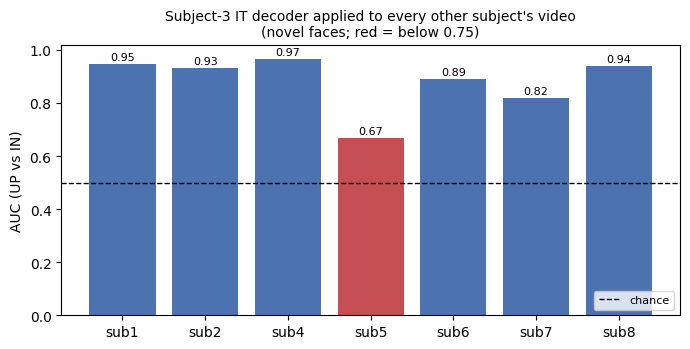

In [3]:
SUBS = sorted(int(p.name[3]) for p in OUT.glob("sub*_cropped.npz"))
rows = []
for s in SUBS:
    if s == TRAIN_SUBJECT:
        continue
    Xte, yte = load_events(s)
    m = DECODER.decision_function(Xte)
    rows.append((s, len(yte), roc_auc_score(yte, m), float(((m > 0) == yte).mean())))

print(f"train = sub{TRAIN_SUBJECT}  ->  test on each other subject's video\n")
print(f"{'test sub':>8}  {'n':>4}  {'AUC':>5}  {'acc':>5}")
for s, n, auc, acc in rows:
    print(f"{s:>8}  {n:>4}  {auc:>5.3f}  {acc:>5.3f}")
aucs = [r[2] for r in rows]
print(f"\nmean cross-video AUC = {np.mean(aucs):.3f}  (median {np.median(aucs):.3f})")

fig, ax = plt.subplots(figsize=(7, 3.6))
xs = [f"sub{r[0]}" for r in rows]
bars = ax.bar(xs, aucs, color=["#4C72B0" if a >= 0.75 else "#C44E52" for a in aucs])
ax.axhline(0.5, ls="--", c="k", lw=1, label="chance")
ax.set_ylim(0, 1.02); ax.set_ylabel("AUC (UP vs IN)")
ax.set_title(f"Subject-{TRAIN_SUBJECT} {LAYER} decoder applied to every other subject's video\n"
             f"(novel faces; red = below 0.75)", fontsize=10)
for b, a in zip(bars, aucs):
    ax.text(b.get_x() + b.get_width()/2, a + 0.015, f"{a:.2f}", ha="center", fontsize=8)
ax.legend(loc="lower right", fontsize=8); plt.tight_layout(); plt.show()

## 3. See the novel faces — gallery with the decoder's live call

The most direct version of *"pass in a face and it tells you upright vs inverted"*: we
rebuild the **actual face crops** of one held-out subject (`TEST_SUBJECT`) straight from
their video — reproducing the cache pipeline exactly (column-K times, YuNet detection,
`crop_to_face`) — so crop *i* is precisely the stimulus behind cached event *i*. Each
crop is labelled with its **true** orientation and the **decoder's** call; green = correct,
red = wrong. These are real faces the subject-3 decoder never trained on.

sub4: 74 novel faces  |  AUC=0.966  acc=0.892


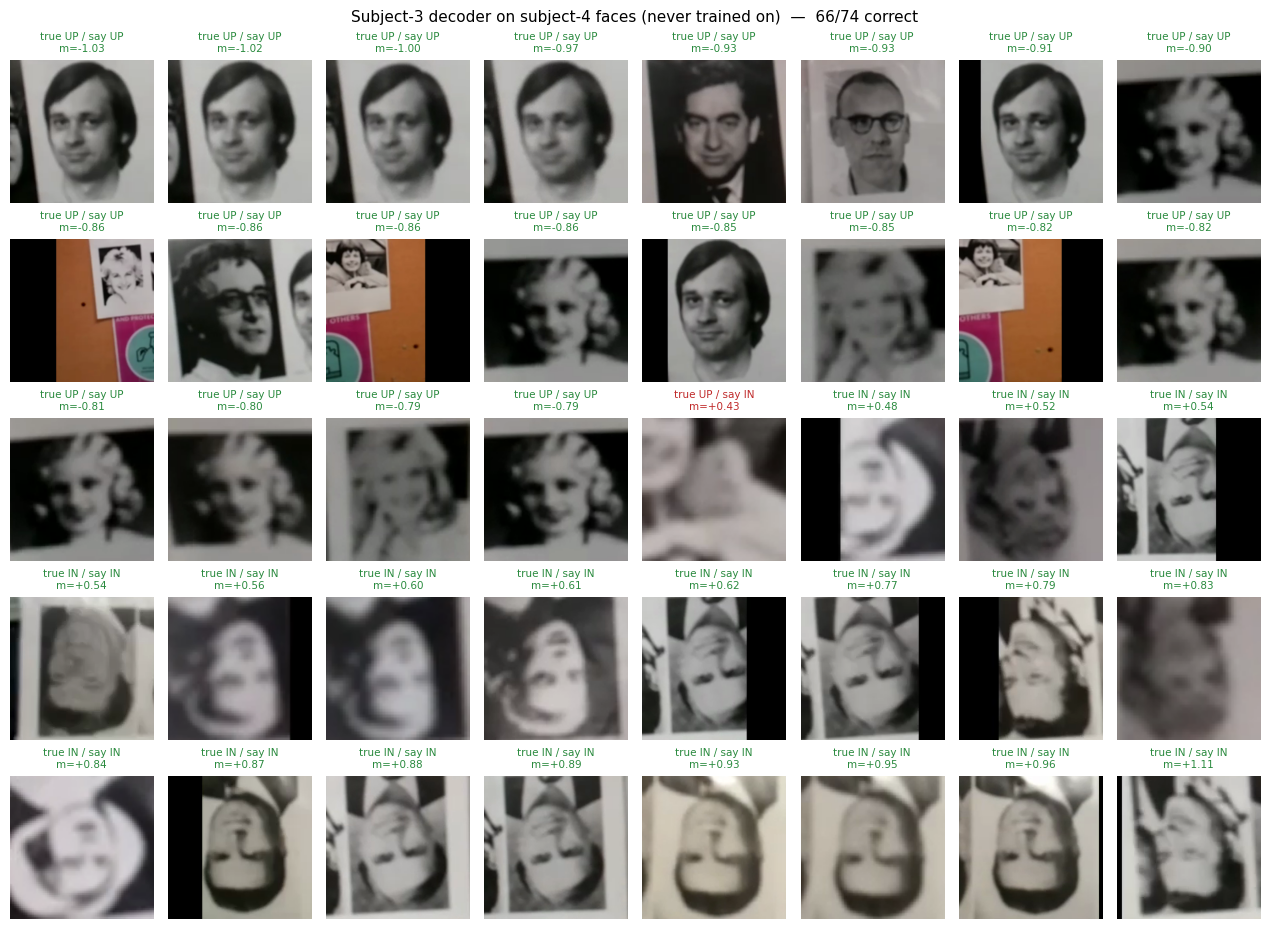

In [4]:
TEST_SUBJECT = 4            # any subject != TRAIN_SUBJECT with a strong AUC above
MAX_SHOW     = 40          # cap the gallery size for readability

def rebuild_crops(sub):
    "Face crops in the SAME order as the cached events (mirrors extract_subject exactly)."
    events = yu.xlsx_face_events(sub)
    roles  = yu.pair_roles([tv for tv, _ in events])
    cap, fps, n_frames = cu.open_video(sub)
    dur = n_frames / fps
    crops, labels = [], []
    try:
        for (tv, label), role in zip(events, roles):
            if not (0 <= tv < dur):
                continue
            frame = cu.grab_frame(cap, tv, fps)
            if frame is None:
                continue
            bbox = yu.detect_face_bbox(frame, min_confidence=yu.YUNET_THRESH,
                                       return_confidence=False, role=role)
            crops.append(cu.crop_to_face(frame, bbox))
            labels.append(str(label).strip().upper())
    finally:
        cap.release()
    return crops, np.array(labels)

crops, labels = rebuild_crops(TEST_SUBJECT)
Xte, yte = load_events(TEST_SUBJECT)
assert len(crops) == len(yte), f"crop/cache mismatch: {len(crops)} vs {len(yte)}"
margins = DECODER.decision_function(Xte)                 # >0 => IN
pred_in = margins > 0
correct = pred_in == yte
print(f"sub{TEST_SUBJECT}: {len(yte)} novel faces  |  "
      f"AUC={roc_auc_score(yte, margins):.3f}  acc={correct.mean():.3f}")

# show a margin-sorted, balanced-ish selection so both confident hits and any misses appear
order = np.argsort(margins)
sel = order if len(order) <= MAX_SHOW else np.concatenate([order[:MAX_SHOW//2], order[-MAX_SHOW//2:]])
cols = 8; nrow = int(np.ceil(len(sel) / cols))
fig, axes = plt.subplots(nrow, cols, figsize=(cols * 1.6, nrow * 1.9))
for ax in np.ravel(axes):
    ax.axis("off")
for ax, i in zip(np.ravel(axes), sel):
    ax.imshow(crops[i]); ax.axis("off")
    truth = "IN" if yte[i] else "UP"
    pred  = "IN" if pred_in[i] else "UP"
    col = "#2a8a3e" if correct[i] else "#c02a2a"
    ax.set_title(f"true {truth} / say {pred}\nm={margins[i]:+.2f}", fontsize=7.5, color=col)
    for sp in ax.spines.values():
        sp.set_visible(True); sp.set_color(col); sp.set_linewidth(2)
fig.suptitle(f"Subject-{TRAIN_SUBJECT} decoder on subject-{TEST_SUBJECT} faces "
             f"(never trained on)  —  {int(correct.sum())}/{len(yte)} correct",
             fontsize=11)
plt.tight_layout(); plt.show()

## 4. Why it separates — the decision margin

One number per novel face: the ridge **decision margin** (`>0` → the decoder says IN).
Plotted against the true label, a clean split means the two orientations land on opposite
sides of zero. This is the same signal the AUC summarises, shown event by event.

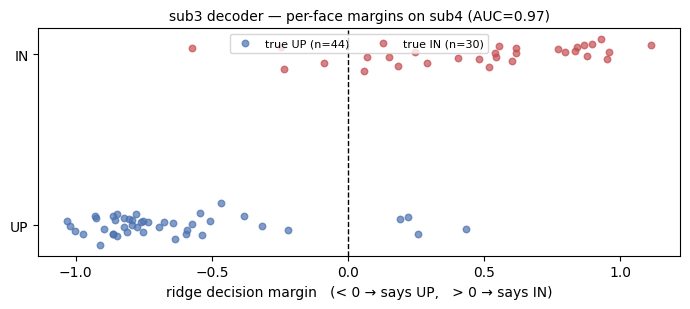

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.2))
rng = np.random.default_rng(RANDOM_SEED)
for val, name, c in [(False, "true UP", "#4C72B0"), (True, "true IN", "#C44E52")]:
    mm = margins[yte == val]
    ax.scatter(mm, rng.normal(0 if not val else 1, 0.06, mm.size), s=22, alpha=0.7,
               color=c, label=f"{name} (n={mm.size})")
ax.axvline(0, ls="--", c="k", lw=1)
ax.set_yticks([0, 1]); ax.set_yticklabels(["UP", "IN"])
ax.set_xlabel("ridge decision margin   (< 0 → says UP,   > 0 → says IN)")
ax.set_title(f"sub{TRAIN_SUBJECT} decoder — per-face margins on sub{TEST_SUBJECT} "
             f"(AUC={roc_auc_score(yte, margins):.2f})", fontsize=10)
ax.legend(fontsize=8, loc="upper center", ncol=2); plt.tight_layout(); plt.show()

## 5. Predictions

stress image: https://img.magnific.com/free-photo/portrait-white-man-isolated_53876-40306.jpg?semt=ais_hybrid&w=740&q=80


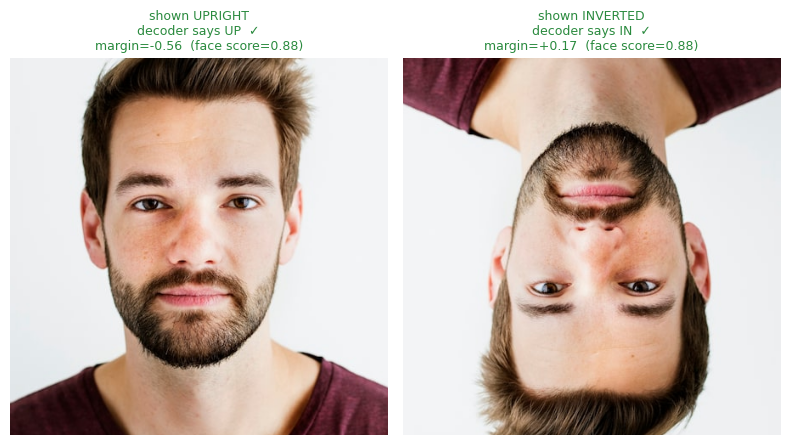

In [11]:
_MODEL, _ACTS, _ = cu.load_model_and_hooks(cu.LAYERS)

def load_image(src):
    "Path or http(s) URL -> RGB uint8 ndarray, EXIF-corrected."
    if isinstance(src, str) and src.lower().startswith(("http://", "https://")):
        req = urllib.request.Request(src, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req, timeout=30) as r:
            data = r.read()
        try:
            img = Image.open(io.BytesIO(data))
            img.load()
        except Exception as e:
            raise ValueError(
                f"URL did not return a decodable image ({e}). Use a DIRECT link to the "
                f"image file itself (ending in .jpg/.png), not the web page it sits on."
            ) from e
    else:
        img = Image.open(src)
    return np.asarray(ImageOps.exif_transpose(img).convert("RGB"))

def image_to_IT(rgb, invert):
    frame = np.rot90(rgb, 2).copy() if invert else rgb        # 180° pixel flip = 'IN'
    bbox, score = yu.detect_face_bbox(frame, return_confidence=True)
    crop = cu.crop_to_face(frame, bbox)                        # falls back to central square
    vec = cu.frame_to_features(crop, _MODEL, _ACTS, cu.LAYERS)[LAYER].astype(np.float32)
    return vec, crop, score

def stress_test(src, title=None):
    rgb = load_image(src)
    res = []
    for name, inv in [("shown UPRIGHT", False), ("shown INVERTED", True)]:
        vec, crop, score = image_to_IT(rgb, inv)
        m = float(DECODER.decision_function(vec[None, :])[0])
        res.append(dict(name=name, crop=crop, score=score, m=m,
                        pred="IN" if m > 0 else "UP", ok=(m > 0) == inv))
    if res[0]["score"] is not None and res[0]["score"] < yu.YUNET_THRESH:
        print(f"note: no confident face found (score={res[0]['score']:.2f} < {yu.YUNET_THRESH}); "
              "CORnet saw a centre crop, not a face — result is meaningless. Try a clearer portrait.")
    fig, axes = plt.subplots(1, 2, figsize=(8, 4.6))
    for ax, r in zip(axes, res):
        ax.imshow(r["crop"]); ax.axis("off")
        col = "#2a8a3e" if r["ok"] else "#c02a2a"
        sc = r["score"] if r["score"] is not None else float("nan")
        ax.set_title(f"{r['name']}\ndecoder says {r['pred']}  {'✓' if r['ok'] else '✗'}\n"
                     f"margin={r['m']:+.2f}  (face score={sc:.2f})", fontsize=9, color=col)
    plt.tight_layout(); plt.show()
    return res

# --- Try your own online face here ---------------------------------------------------
# Paste a DIRECT image link into IMAGE_URL: it must point straight at the image file
# (URL ends in .jpg / .jpeg / .png), NOT the web page the photo is displayed on.
#   • On any photo in your browser: right-click -> "Copy image address".
#   • On Wikimedia Commons: open the file page and copy the "Original file" link
#     (the .../commons/x/xx/Name.jpg form). Note the smaller .../thumb/.../NNNpx-...
#     preview links are hotlink-blocked and will fail — use the Original file link.

# Leave IMAGE_URL = None to fall back to a bundled sample.
IMAGE_URL = 'https://img.magnific.com/free-photo/portrait-white-man-isolated_53876-40306.jpg?semt=ais_hybrid&w=740&q=80'

STRESS_IMAGE = IMAGE_URL if IMAGE_URL else str(next(SAMPLES.glob("*.jpg")))
print(f"stress image: {STRESS_IMAGE}")
_ = stress_test(STRESS_IMAGE)